<a href="https://colab.research.google.com/github/Asritha0507/ML-Market-Basket-Analysis/blob/main/07_Explainability_Scalability_and_Final_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

file_path = "/content/drive/MyDrive/ML_Market_Basket_Analysis/04_Results/feature_importance.csv"

feature_importance = pd.read_csv(file_path)

print("Loaded successfully!")
print(feature_importance)

Mounted at /content/drive
Loaded successfully!
                     Feature  Importance
0     times_purchased_before    0.422621
1      first_purchase_before    0.411592
2             recency_before    0.071739
3       last_purchase_before    0.017755
4       purchase_span_before    0.012547
5         total_items_before    0.012370
6              department_id    0.011423
7                   aisle_id    0.008179
8          avg_basket_before    0.007022
9            previous_orders    0.006276
10         max_basket_before    0.005844
11              order_number    0.005205
12    days_since_prior_order    0.002457
13                 order_dow    0.001690
14         order_hour_of_day    0.001670
15            order_progress    0.001609
16  was_previously_purchased    0.000000


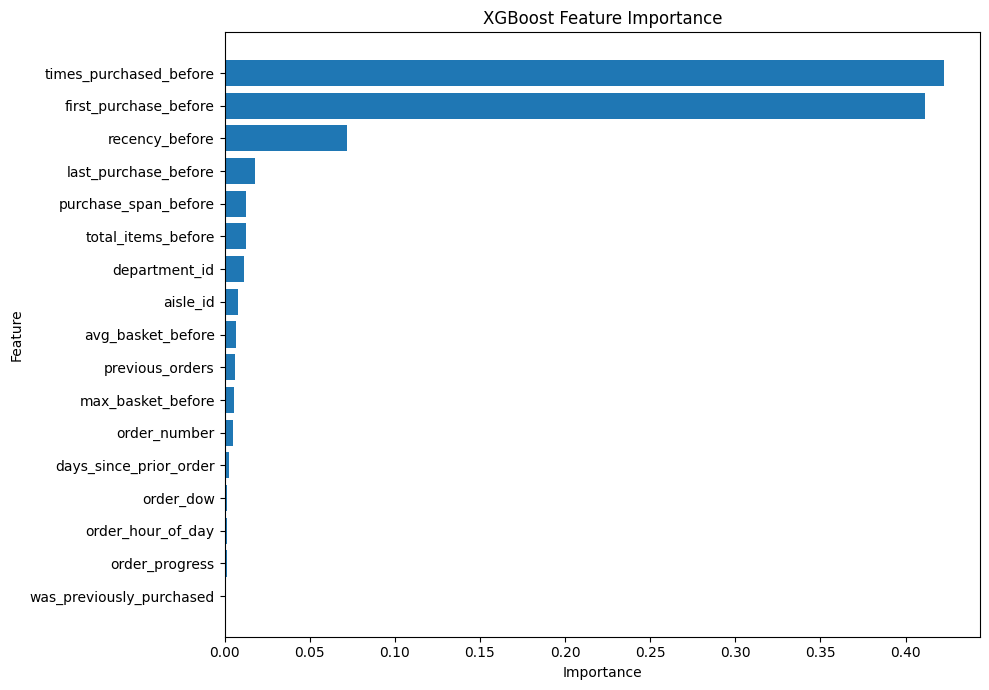

In [ ]:
import matplotlib.pyplot as plt

fi = feature_importance.sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(fi["Feature"], fi["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
top_features = feature_importance.sort_values("Importance", ascending=False)

top_5_share = top_features.head(5)["Importance"].sum()
top_10_share = top_features.head(10)["Importance"].sum()

print("Top 5 features account for:", round(top_5_share * 100, 2), "% of total importance")
print("Top 10 features account for:", round(top_10_share * 100, 2), "% of total importance")

Top 5 features account for: 93.63 % of total importance
Top 10 features account for: 98.15 % of total importance


In [ ]:
import os
import pandas as pd

engineered_path = "/content/drive/MyDrive/ML_Market_Basket_Analysis/02_Datasets/Engineered_Features"

files = sorted([
    f for f in os.listdir(engineered_path)
    if f.endswith(".parquet")
])

total_rows = 0

for f in files:
    df = pd.read_parquet(os.path.join(engineered_path, f), columns=["order_id"])
    total_rows += len(df)

print("Engineered feature chunks:", len(files))
print("Total candidate rows processed:", f"{total_rows:,}")
print("Average rows per chunk:", f"{total_rows / len(files):,.0f}")

Engineered feature chunks: 99
Total candidate rows processed: 74,633,064
Average rows per chunk: 753,869


In [ ]:
import os

total_size = 0

for f in files:
    total_size += os.path.getsize(os.path.join(engineered_path, f))

size_gb = total_size / (1024 ** 3)

print("Engineered dataset storage:", round(size_gb, 2), "GB")
print("Average chunk size:", round(size_gb / len(files), 2), "GB")

Engineered dataset storage: 0.37 GB
Average chunk size: 0.0 GB


In [ ]:
total_size_mb = total_size / (1024 ** 2)
average_chunk_mb = total_size_mb / len(files)

print("Total engineered dataset:", round(total_size_mb, 2), "MB")
print("Average chunk size:", round(average_chunk_mb, 2), "MB")


Total engineered dataset: 374.74 MB
Average chunk size: 3.79 MB


In [ ]:
train_rows = 0
val_rows = 0
train_positive = 0
val_positive = 0

for f in files:
    df = pd.read_parquet(
        os.path.join(engineered_path, f),
        columns=["order_number", "in_next_basket"]
    )

    train = df["order_number"] <= 50
    val = df["order_number"] >= 51

    train_rows += train.sum()
    val_rows += val.sum()
    train_positive += ((df["in_next_basket"] == 1) & train).sum()
    val_positive += ((df["in_next_basket"] == 1) & val).sum()

print("Training rows:", f"{train_rows:,}")
print("Validation rows:", f"{val_rows:,}")
print("Training positives:", f"{train_positive:,}")
print("Validation positives:", f"{val_positive:,}")
print("Train positive rate:", round(train_positive / train_rows * 100, 2), "%")
print("Validation positive rate:", round(val_positive / val_rows * 100, 2), "%")

Training rows: 72,403,477
Validation rows: 2,229,587
Training positives: 3,472,479
Validation positives: 106,926
Train positive rate: 4.8 %
Validation positive rate: 4.8 %


In [ ]:
print("SCALABILITY SUMMARY")
print("-" * 35)
print("Original prior interactions :", f"{32_434_489:,}")
print("Engineered candidate rows   :", f"{total_rows:,}")
print("Engineered feature chunks   :", len(files))
print("Training rows               :", f"{train_rows:,}")
print("Validation rows             :", f"{val_rows:,}")

SCALABILITY SUMMARY
-----------------------------------
Original prior interactions : 32,434,489
Engineered candidate rows   : 74,633,064
Engineered feature chunks   : 99
Training rows               : 72,403,477
Validation rows             : 2,229,587


In [ ]:
top_10 = feature_importance.sort_values("Importance", ascending=False).head(10)

print("Top 10 Model Features")
print("-" * 45)

for i, row in top_10.reset_index(drop=True).iterrows():
    print(f"{i+1:2}. {row['Feature']:<30} {row['Importance']:.4f}")

Top 10 Model Features
---------------------------------------------
 1. times_purchased_before         0.4226
 2. first_purchase_before          0.4116
 3. recency_before                 0.0717
 4. last_purchase_before           0.0178
 5. purchase_span_before           0.0125
 6. total_items_before             0.0124
 7. department_id                  0.0114
 8. aisle_id                       0.0082
 9. avg_basket_before              0.0070
10. previous_orders                0.0063


In [ ]:
summary = {
    "Original prior interactions": 32_434_489,
    "Engineered candidate rows": 74_633_064,
    "Feature chunks": 99,
    "Training rows": 72_403_477,
    "Validation rows": 2_229_587,
    "Training positive rate (%)": 4.8,
    "Validation positive rate (%)": 4.8,
    "Top 5 feature importance (%)": 93.63,
    "Top 10 feature importance (%)": 98.15
}

summary_df = pd.DataFrame(
    list(summary.items()),
    columns=["Metric", "Value"]
)

display(summary_df)


,Metric,Value
0,Original prior interactions,32434489.00
1,Engineered candidate rows,74633064.00
2,Feature chunks,99.00
3,Training rows,72403477.00
4,Validation rows,2229587.00
5,Training positive rate (%),4.80
6,Validation positive rate (%),4.80
7,Top 5 feature importance (%),93.63
8,Top 10 feature importance (%),98.15


In [ ]:
comparison_path = "/content/drive/MyDrive/ML_Market_Basket_Analysis/04_Results/model_comparison.csv"

model_comparison = pd.read_csv(comparison_path)

print("Model comparison loaded successfully!")
display(model_comparison)

Model comparison loaded successfully!


,K,Precision_XGBoost,Recall_XGBoost,NDCG_XGBoost,Precision_Baseline,Recall_Baseline,NDCG_Baseline,Precision_Improvement,Recall_Improvement,NDCG_Improvement
0,5,0.595067,0.468219,0.704387,0.551289,0.440367,0.659945,0.043778,0.027852,0.044442
1,10,0.457635,0.641392,0.702032,0.423902,0.610921,0.658185,0.033733,0.030471,0.043847
2,20,0.313955,0.793049,0.738254,0.296446,0.775007,0.699929,0.017509,0.018042,0.038325


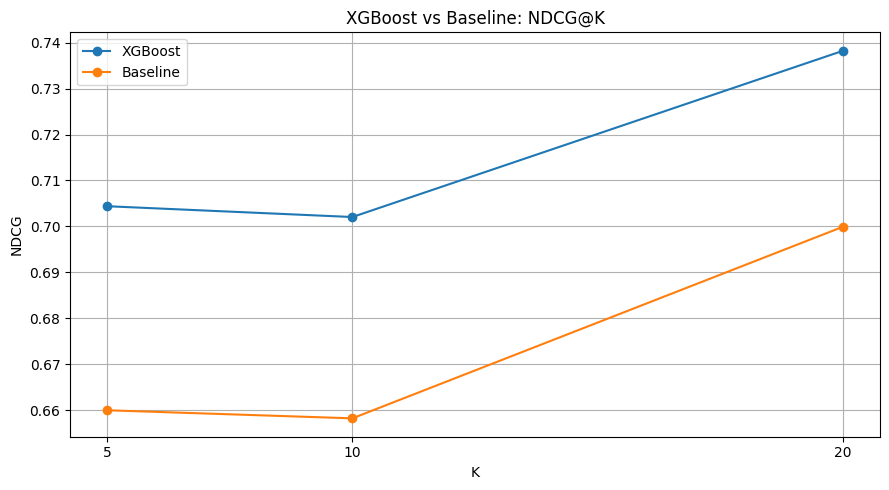

In [ ]:
import matplotlib.pyplot as plt

k = model_comparison["K"]

plt.figure(figsize=(9, 5))
plt.plot(k, model_comparison["NDCG_XGBoost"], marker="o", label="XGBoost")
plt.plot(k, model_comparison["NDCG_Baseline"], marker="o", label="Baseline")

plt.xlabel("K")
plt.ylabel("NDCG")
plt.title("XGBoost vs Baseline: NDCG@K")
plt.xticks(k)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
final_results = pd.DataFrame({
    "K": model_comparison["K"],
    "XGBoost Precision": model_comparison["Precision_XGBoost"],
    "Baseline Precision": model_comparison["Precision_Baseline"],
    "XGBoost Recall": model_comparison["Recall_XGBoost"],
    "Baseline Recall": model_comparison["Recall_Baseline"],
    "XGBoost NDCG": model_comparison["NDCG_XGBoost"],
    "Baseline NDCG": model_comparison["NDCG_Baseline"]
})

display(final_results.round(4))

,K,XGBoost Precision,Baseline Precision,XGBoost Recall,Baseline Recall,XGBoost NDCG,Baseline NDCG
0,5,0.5951,0.5513,0.4682,0.4404,0.7044,0.6599
1,10,0.4576,0.4239,0.6414,0.6109,0.7020,0.6582
2,20,0.3140,0.2964,0.7930,0.7750,0.7383,0.6999


In [ ]:
final_summary = pd.DataFrame({
    "Metric": [
        "Original prior interactions",
        "Engineered candidate rows",
        "Feature chunks",
        "Training rows",
        "Validation rows",
        "Training positive rate (%)",
        "Validation positive rate (%)",
        "Top 5 feature importance (%)",
        "Top 10 feature importance (%)",
        "Best Precision@5",
        "Best Recall@20",
        "Best NDCG@20"
    ],
    "Value": [
        32434489,
        74633064,
        99,
        72403477,
        2229587,
        4.8,
        4.8,
        93.63,
        98.15,
        0.5951,
        0.7930,
        0.7383
    ]
})

summary_path = "/content/drive/MyDrive/ML_Market_Basket_Analysis/04_Results/final_project_summary.csv"
final_summary.to_csv(summary_path, index=False)

print("Final project summary saved successfully!")
print(summary_path)
display(final_summary)

Final project summary saved successfully!
/content/drive/MyDrive/ML_Market_Basket_Analysis/04_Results/final_project_summary.csv


,Metric,Value
0,Original prior interactions,3.243449e+07
1,Engineered candidate rows,7.463306e+07
2,Feature chunks,9.900000e+01
3,Training rows,7.240348e+07
4,Validation rows,2.229587e+06
5,Training positive rate (%),4.800000e+00
6,Validation positive rate (%),4.800000e+00
7,Top 5 feature importance (%),9.363000e+01
8,Top 10 feature importance (%),9.815000e+01
9,Best Precision@5,5.951000e-01
